In [ ]:
from google.colab import files
uploaded = files.upload()

Saving penguins_size.csv to penguins_size.csv


In [ ]:
import pandas as pd
df = pd.read_csv('/content/penguins_size.csv')
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [ ]:
df.dropna(inplace=True)
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [ ]:
df['sex'].unique()

array(['MALE', 'FEMALE', '.'], dtype=object)

In [ ]:
df[df['sex']=='.']

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.


In [ ]:
df.drop(axis=0, inplace=True, index=336)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   culmen_length_mm   333 non-null    float64
 3   culmen_depth_mm    333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [ ]:
df['species'].value_counts()

,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


펭귄 종별 빈도수 구하기

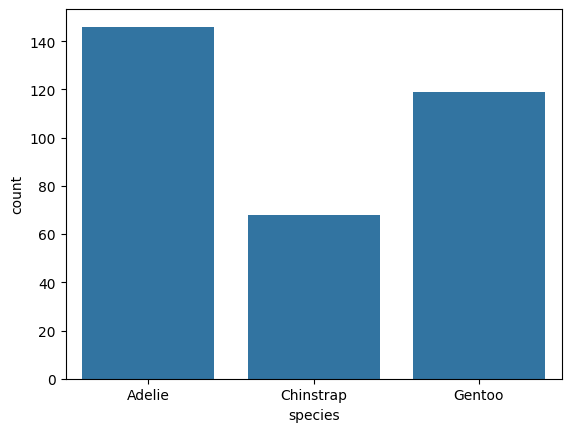

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='species', data=df)
plt.show()

박스 플롯으로 시각화하기

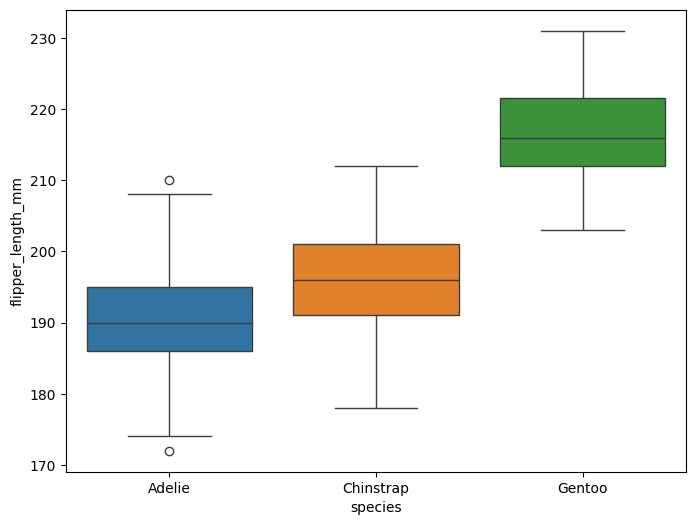

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='species', y='flipper_length_mm', hue='species', data=df)
plt.show()

산점도로 시각화하기

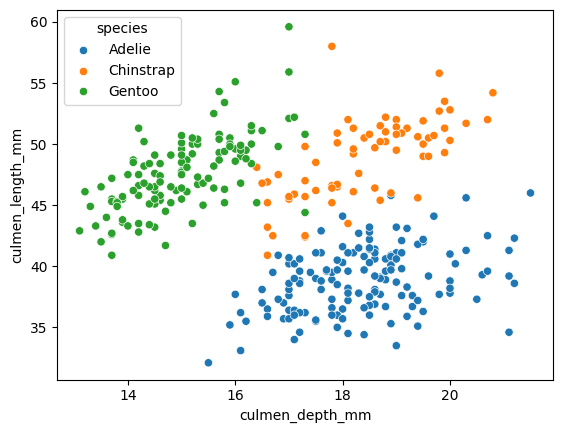

In [ ]:
sns.scatterplot(x='culmen_depth_mm', y='culmen_length_mm',
hue='species', data=df)
plt.show()

In [ ]:
df1 = df[['culmen_depth_mm', 'culmen_length_mm', 'flipper_length_mm','species']]
df1.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm,species
0,18.7,39.1,181.0,Adelie
1,17.4,39.5,186.0,Adelie
2,18.0,40.3,195.0,Adelie
4,19.3,36.7,193.0,Adelie
5,20.6,39.3,190.0,Adelie


In [ ]:
dataset = df1.values
X = dataset[:, :-1]
y = dataset[:, -1]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

array([0.66666667, 0.25454545, 0.15254237])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=0)

최근접 이웃 알고리즘

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
print("테스트 데이터를 이용한 모델 성능 평가 : ", knn.score(X_test,y_test))

테스트 데이터를 이용한 모델 성능 평가 :  0.97


In [ ]:
for k in range(2, 11):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  score = knn.score(X_test, y_test)
  print('k: %d, accuracy: %.2f' % (k, score*100))

k: 2, accuracy: 95.00
k: 3, accuracy: 96.00
k: 4, accuracy: 96.00
k: 5, accuracy: 97.00
k: 6, accuracy: 96.00
k: 7, accuracy: 97.00
k: 8, accuracy: 97.00
k: 9, accuracy: 97.00
k: 10, accuracy: 97.00


In [ ]:
predictions = knn.predict(X_test)

In [ ]:
print(predictions[:5])
print(y_test[:5])

['Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie']
['Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie']


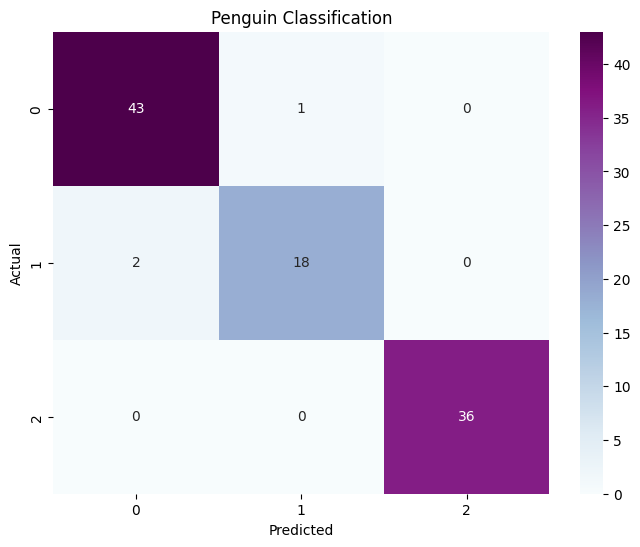

In [ ]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8,6))

conf = confusion_matrix(y_test, predictions)
sns.heatmap(conf, annot=True, cmap='BuPu')

plt.title("Penguin Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving penguin_new.csv to penguin_new.csv


In [ ]:
df_new = pd.read_csv('/content/penguin_new.csv')
df_new.head()

,culmen_depth_mm,culmen_length_mm,flipper_length_mm
0,18.7,39.1,181
1,18.5,46.9,200
2,14.5,50.0,250


In [ ]:
dataset_new = df_new.values
new_scaled = scaler.fit_transform(dataset_new)

In [ ]:
print(knn.predict(new_scaled))

['Adelie' 'Chinstrap' 'Gentoo']
